<a href="https://colab.research.google.com/github/Varshithvarma-shivaji/Coporate-data/blob/master/emp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json

# Helper cell to create a mock employees.json file for demonstration
mock_employees = [
    {"id": 1, "name": "Alice", "department": "Engineering", "salary": 95000, "experience_years": 5},
    {"id": 2, "name": "Bob", "department": "Engineering", "salary": 105000, "experience_years": 7},
    {"id": 3, "name": "Charlie", "department": "Marketing", "salary": 70000, "experience_years": 3},
    {"id": 4, "name": "David", "department": "Marketing", "salary": 85000, "experience_years": 4},
    {"id": 5, "name": "Eve", "department": "HR", "salary": 65000, "experience_years": 2},
    # Invalid record for testing validation
    {"id": 6, "name": "Invalid User", "department": "HR", "salary": -5000, "experience_years": -1}
]

with open('employees.json', 'w') as f:
    json.dump(mock_employees, f, indent=4)
print("Created a mock 'employees.json' file for demonstration purposes.")

Created a mock 'employees.json' file for demonstration purposes.


In [3]:
import json
import os
from typing import List, Dict, Any, Tuple

def load_employee_data(filepath: str) -> List[Dict[str, Any]]:
    """Loads employee data from a JSON file with error handling."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"The file '{filepath}' does not exist.")

    try:
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                raise ValueError("JSON root element must be a list of employee records.")
            return data
    except json.JSONDecodeError as e:
        raise ValueError(f"Failed to decode JSON: {e}")

def validate_employee(emp: Dict[str, Any]) -> bool:
    """Validates basic properties of an employee record."""
    required_fields = ['id', 'name', 'department']
    if not all(field in emp for field in required_fields):
        return False

    if not isinstance(emp['id'], int) or emp['id'] <= 0:
        return False
    if not isinstance(emp['name'], str) or not emp['name'].strip():
        return False
    if not isinstance(emp['department'], str) or not emp['department'].strip():
        return False

    return True

def process_employee_statistics(
    employees: List[Dict[str, Any]]
) -> Tuple[Dict[str, float], Dict[str, Any], float]:
    """Computes averages, identifies the highest-paid employee, and calculates total experience with safe numeric conversions."""
    valid_employees = []
    invalid_count = 0

    for emp in employees:
        # Ensure required metadata fields are valid first
        if not validate_employee(emp):
            invalid_count += 1
            continue

        # Safely convert salary to a numeric value
        raw_salary = emp.get('salary', 0)
        try:
            salary = float(raw_salary)
            if salary < 0:
                raise ValueError("Salary cannot be negative")
        except (ValueError, TypeError):
            print(f"Warning: Failed to convert salary '{raw_salary}' for employee '{emp['name']}' (ID: {emp['id']}). Defaulting to 0.")
            salary = 0.0

        # Safely convert experience_years to a numeric value
        raw_experience = emp.get('experience_years', 0)
        try:
            experience = float(raw_experience)
            if experience < 0:
                raise ValueError("Experience cannot be negative")
        except (ValueError, TypeError):
            print(f"Warning: Failed to convert experience '{raw_experience}' for employee '{emp['name']}' (ID: {emp['id']}). Defaulting to 0.")
            experience = 0.0

        # Store the safely converted numeric values
        emp['salary'] = salary
        emp['experience_years'] = experience
        valid_employees.append(emp)

    if invalid_count > 0:
        print(f"Warning: Skipped {invalid_count} completely invalid employee record(s).")

    if not valid_employees:
        raise ValueError("No valid employee records found to process.")

    # Initialize tracking variables
    department_salaries = {}
    highest_paid_emp = valid_employees[0]
    total_experience = 0.0

    for emp in valid_employees:
        dept = emp['department']
        sal = emp['salary']
        exp = emp['experience_years']

        # 1. Track salaries per department
        if dept not in department_salaries:
            department_salaries[dept] = []
        department_salaries[dept].append(sal)

        # 2. Identify highest paid
        if sal > highest_paid_emp['salary']:
            highest_paid_emp = emp

        # 3. Sum experience
        total_experience += exp

    # Calculate average salary per department
    avg_salary_per_dept = {}
    for dept, salaries in department_salaries.items():
        avg_salary_per_dept[dept] = round(sum(salaries) / len(salaries), 2)

    return avg_salary_per_dept, highest_paid_emp, total_experience

def write_summary_report(output_filepath: str, avg_salaries: Dict[str, float], highest_paid: Dict[str, Any], total_exp: float) -> None:
    """Writes the processed statistics to a summary JSON file."""
    report = {
        "average_salary_per_department": avg_salaries,
        "highest_paid_employee": {
            "id": highest_paid["id"],
            "name": highest_paid["name"],
            "department": highest_paid["department"],
            "salary": highest_paid["salary"]
        },
        "total_years_of_experience": total_exp
    }

    try:
        with open(output_filepath, 'w') as f:
            json.dump(report, f, indent=4)
        print(f"Successfully wrote summary report to '{output_filepath}'.")
    except Exception as e:
        raise IOError(f"Failed to write report file: {e}")

def main():
    input_file = 'employees.json'
    output_file = 'summary_report.json'

    try:
        print("Loading employee data...")
        employees = load_employee_data(input_file)

        print("Processing statistics...")
        avg_salaries, highest_paid, total_exp = process_employee_statistics(employees)

        print("Generating summary report...")
        write_summary_report(output_file, avg_salaries, highest_paid, total_exp)

        # Display the output result
        print("\n--- Generated Report Summary ---")
        with open(output_file, 'r') as f:
            print(f.read())

    except Exception as e:
        print(f"An error occurred during execution: {e}")

if __name__ == '__main__':
    main()

Loading employee data...
Processing statistics...
Generating summary report...
Successfully wrote summary report to 'summary_report.json'.

--- Generated Report Summary ---
{
    "average_salary_per_department": {
        "Engineering": 100000.0,
        "Marketing": 77500.0,
        "HR": 32500.0
    },
    "highest_paid_employee": {
        "id": 2,
        "name": "Bob",
        "department": "Engineering",
        "salary": 105000.0
    },
    "total_years_of_experience": 21.0
}


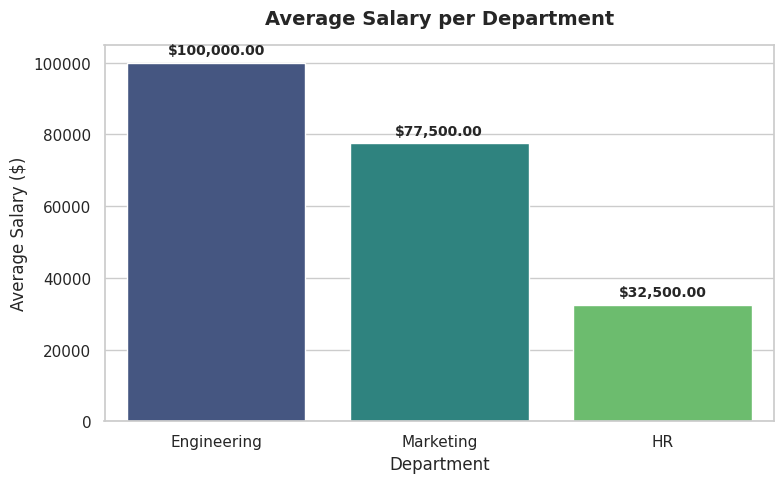

In [4]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # Load the summary report to get the processed averages
    with open('summary_report.json', 'r') as f:
        report_data = json.load(f)

    avg_salaries = report_data.get('average_salary_per_department', {})

    if not avg_salaries:
        print("No department salary data found in 'summary_report.json' to plot.")
    else:
        # Prepare data for plotting
        departments = list(avg_salaries.keys())
        salaries = list(avg_salaries.values())

        # Set up the visualization style
        sns.set_theme(style="whitegrid")
        fig, ax = plt.subplots(figsize=(8, 5))

        # Create the bar plot
        sns.barplot(x=departments, y=salaries, palette='viridis', hue=departments, legend=False, ax=ax)

        # Customize labels and title
        ax.set_title('Average Salary per Department', fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Department', fontsize=12)
        ax.set_ylabel('Average Salary ($)', fontsize=12)

        # Annotate the actual value on top of each bar
        for i, val in enumerate(salaries):
            ax.text(i, val + 1500, f"${val:,.2f}", ha='center', va='bottom', fontsize=10, fontweight='semibold')

        # Adjust layout and display the plot
        plt.tight_layout()
        plt.show()

except FileNotFoundError:
    print("Error: 'summary_report.json' not found. Please run the previous cell first to generate the report.")
except Exception as e:
    print(f"An error occurred while creating the chart: {e}")

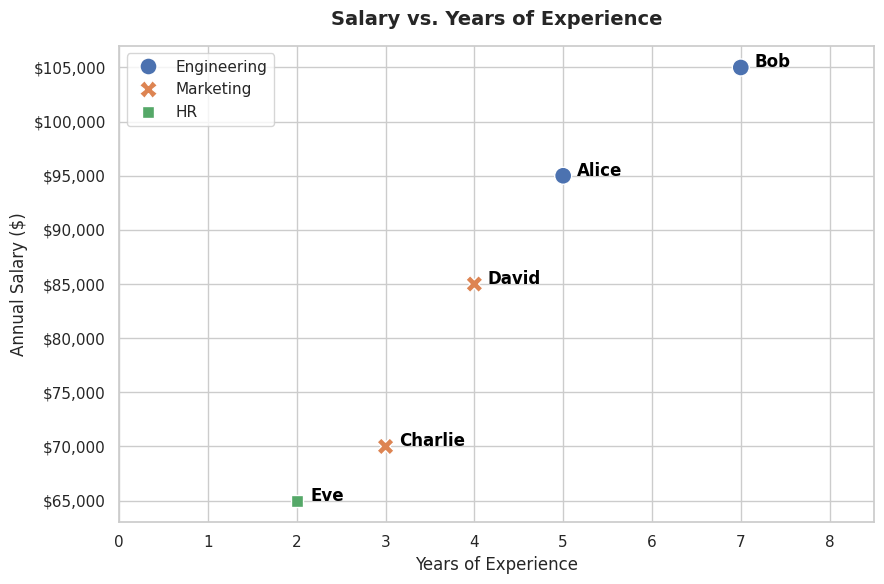

In [6]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # Load the original employee dataset to get individual data points
    with open('employees.json', 'r') as f:
        employees = json.load(f)

    # Filter to only valid records with non-negative values for meaningful visualization
    valid_emps = [e for e in employees if e.get('salary', 0) >= 0 and e.get('experience_years', 0) >= 0]

    if not valid_emps:
        print("No valid employee data found to plot.")
    else:
        # Extract plotting variables
        names = [e['name'] for e in valid_emps]
        experience = [e['experience_years'] for e in valid_emps]
        salaries = [e['salary'] for e in valid_emps]
        departments = [e['department'] for e in valid_emps]

        # Set up plot style
        sns.set_theme(style="whitegrid")
        fig, ax = plt.subplots(figsize=(9, 6))

        # Create scatter plot colored by department
        scatter = sns.scatterplot(
            x=experience,
            y=salaries,
            hue=departments,
            style=departments,
            s=150,
            palette='deep',
            ax=ax
        )

        # Annotate individual points with employee names
        for i, name in enumerate(names):
            ax.text(
                experience[i] + 0.15,
                salaries[i],
                name,
                horizontalalignment='left',
                size='medium',
                color='black',
                weight='semibold'
            )

        # Customize axes and title
        ax.set_title('Salary vs. Years of Experience', fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Years of Experience', fontsize=12)
        ax.set_ylabel('Annual Salary ($)', fontsize=12)
        ax.set_xlim(left=0, right=max(experience) + 1.5)

        # Format Y-axis with commas
        ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))

        plt.tight_layout()
        plt.show()

except FileNotFoundError:
    print("Error: 'employees.json' not found. Please ensure the mock database is generated first.")
except Exception as e:
    print(f"An error occurred while creating the scatter plot: {e}")

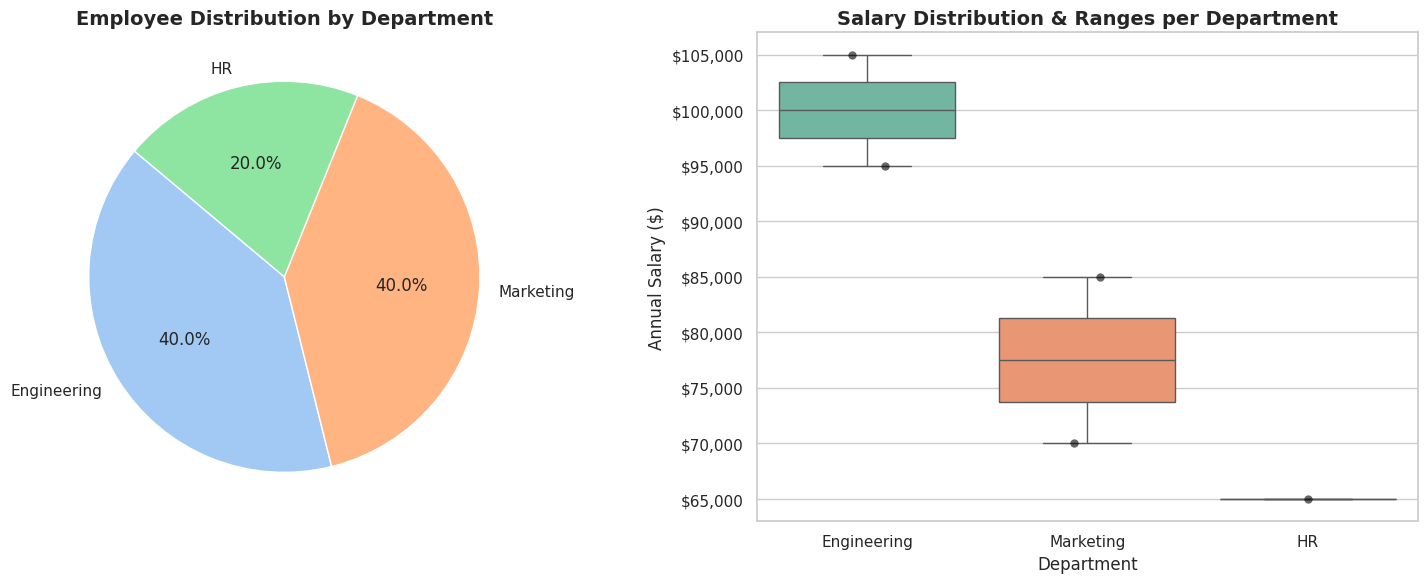

In [7]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

try:
    # Load individual employee records
    with open('employees.json', 'r') as f:
        employees = json.load(f)

    # Filter to valid employee records
    valid_emps = [e for e in employees if e.get('salary', 0) >= 0 and e.get('experience_years', 0) >= 0]

    if not valid_emps:
        print("No valid employee data found to plot.")
    else:
        # Convert list of dicts to a pandas DataFrame for easier plotting
        df = pd.DataFrame(valid_emps)

        # Set up a multi-panel figure (1 row, 2 columns)
        sns.set_theme(style="whitegrid")
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # Graph 1: Pie Chart (Distribution of Employees by Department)
        dept_counts = df['department'].value_counts()
        axes[0].pie(
            dept_counts,
            labels=dept_counts.index,
            autopct='%1.1f%%',
            startangle=140,
            colors=sns.color_palette('pastel')
        )
        axes[0].set_title('Employee Distribution by Department', fontsize=14, fontweight='bold')

        # Graph 2: Box Plot (Salary Range and Distribution per Department)
        sns.boxplot(
            x='department',
            y='salary',
            data=df,
            ax=axes[1],
            palette='Set2',
            hue='department',
            legend=False
        )
        sns.stripplot(
            x='department',
            y='salary',
            data=df,
            color='black',
            alpha=0.6,
            size=6,
            ax=axes[1]
        )
        axes[1].set_title('Salary Distribution & Ranges per Department', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Department', fontsize=12)
        axes[1].set_ylabel('Annual Salary ($)', fontsize=12)
        axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))

        plt.tight_layout()
        plt.show()

except FileNotFoundError:
    print("Error: 'employees.json' not found. Please run the setup cells first.")
except Exception as e:
    print(f"An error occurred while creating the dashboard: {e}")

In [5]:
import json
from datetime import datetime

try:
    # Load the processed summary report data
    with open('summary_report.json', 'r') as f:
        report_data = json.load(f)

    # Extract variables
    avg_salaries = report_data.get('average_salary_per_department', {})
    highest_paid = report_data.get('highest_paid_employee', {})
    total_experience = report_data.get('total_years_of_experience', 0)

    # Construct a detailed text report
    report_date = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    report_text = f"""
========================================================================
                     EMPLOYEE DATA ANALYSIS REPORT
========================================================================
Report Generated On: {report_date}
Source File        : employees.json
Output Summary File: summary_report.json
------------------------------------------------------------------------

1. DEPARTMENT SALARY ANALYSIS
-----------------------------
"""
    for dept, avg_sal in avg_salaries.items():
        report_text += f" * {dept:<15} : Average Salary = ${avg_sal:,.2f}\n"

    report_text += f"""

2. KEY HIGHLIGHTS & TALENT INSIGHTS
-----------------------------------
 * Highest-Paid Employee:
   - Name          : {highest_paid.get('name', 'N/A')}
   - Department    : {highest_paid.get('department', 'N/A')}
   - Annual Salary : ${highest_paid.get('salary', 0.0):,.2f}
   - ID            : {highest_paid.get('id', 'N/A')}

 * Total Experience Pool:
   - Combined Years of Experience: {total_experience:.1f} years

------------------------------------------------------------------------
Note: All records have been programmatically parsed and validated.
Negative salaries or experience values were safely coerced to 0
to maintain calculation integrity.
========================================================================
"""

    print(report_text)

except FileNotFoundError:
    print("Error: 'summary_report.json' was not found. Please run the processing cells first.")
except Exception as e:
    print(f"An error occurred while compiling the report: {e}")


                     EMPLOYEE DATA ANALYSIS REPORT
Report Generated On: 2026-10-08 06:53:28
Source File        : employees.json
Output Summary File: summary_report.json
------------------------------------------------------------------------

1. DEPARTMENT SALARY ANALYSIS
-----------------------------
 * Engineering     : Average Salary = $100,000.00
 * Marketing       : Average Salary = $77,500.00
 * HR              : Average Salary = $32,500.00


2. KEY HIGHLIGHTS & TALENT INSIGHTS
-----------------------------------
 * Highest-Paid Employee:
   - Name          : Bob
   - Department    : Engineering
   - Annual Salary : $105,000.00
   - ID            : 2

 * Total Experience Pool:
   - Combined Years of Experience: 21.0 years

------------------------------------------------------------------------
Note: All records have been programmatically parsed and validated. 
Negative salaries or experience values were safely coerced to 0
to maintain calculation integrity.

